In [1]:
# this installs the packages used in the papa station example
# copernicusmarine is added because glorys data needs it
using Pkg
pkg"add Oceananigans, NumericalEarth, CairoMakie, CopernicusMarine"

# this sets copernicus credentials for the current notebook session
# glorys data comes from copernicus marine; keep real credentials local + private
ENV["COPERNICUS_USERNAME"] = "msingh12"
ENV["COPERNICUS_PASSWORD"] = "Meghicopernicus10!"

┌ Warning: The Pkg REPL mode is intended for interactive use only, and should not be used from scripts. It is recommended to use the functional API instead.
└ @ Pkg.REPLMode C:\Users\meghn\.julia\juliaup\julia-1.12.6+0.x64.w64.mingw32\share\julia\stdlib\v1.12\Pkg\src\REPLMode\REPLMode.jl:398
   Resolving package versions...
    Updating `C:\Users\meghn\.julia\environments\v1.12\Project.toml`
  [13f3f980] + CairoMakie v0.15.12
  [cd43e856] + CopernicusMarine v0.2.0
  [904d977b] + NumericalEarth v0.5.7
  [9e8cae18] + Oceananigans v0.110.4
    Updating `C:\Users\meghn\.julia\environments\v1.12\Manifest.toml`
  [621f4979] + AbstractFFTs v1.5.0
  [1520ce14] + AbstractTrees v0.4.5
  [7d9f7c33] + Accessors v0.1.44
  [79e6a3ab] + Adapt v4.6.1
  [35492f91] + AdaptivePredicates v1.2.0
  [66dad0bd] + AliasTables v1.1.3
  [27a7e980] + Animations v0.4.2
  [4fba245c] + ArrayInterface v7.25.0
  [a9b6321e] + Atomix v1.1.3
  [67c07d97] + Automa v1.2.0
  [13072b0f] + AxisAlgorithms v1.1.0
  [39de3d68] +

"Meghicopernicus10!"

In [4]:
# copernicusmarine handles the glorys data access
# numericalearth provides the data helpers + ocean simulation constructor
# oceananigans is the actual model framework
using CopernicusMarine
using NumericalEarth
using Oceananigans
using Oceananigans: prognostic_fields
using Oceananigans.Units
using Oceananigans.Models: buoyancy_frequency
using Dates
using Printf

# this names the station for saved output files
location_name = "ocean_station_papa"

# this sets the papa station longitude + latitude
# negative longitude means west; 50.1 is north
λ★, φ★ = -144.9, 50.1

# this builds a single water column with 2 m spacing
# x + y are flat; z runs from -400 m to the surface
grid = RectilinearGrid(size = 200,
                       x = λ★,
                       y = φ★,
                       z = (-400, 0),
                       topology = (Flat, Flat, Bounded))

# this builds the ocean simulation on the single-column grid
# coriolis uses an f-plane at papa station latitude
ocean = ocean_simulation(grid; Δt=10minutes, coriolis=FPlane(latitude = φ★))

# this shows the wrapped ocean model
# useful for seeing tracers, closure, grid, and coriolis setup
ocean.model

# this defines the single data column to pull from glorys
# nearest uses the closest available grid point
col = Column(λ★, φ★; interpolation=Nearest())

# this sets initial temperature + salinity from glorys monthly data
# T maps to temperature; S maps to salinity
set!(ocean.model, T=Metadatum(:temperature, dataset=GLORYSMonthly(), region=col),
                  S=Metadatum(:salinity,    dataset=GLORYSMonthly(), region=col))

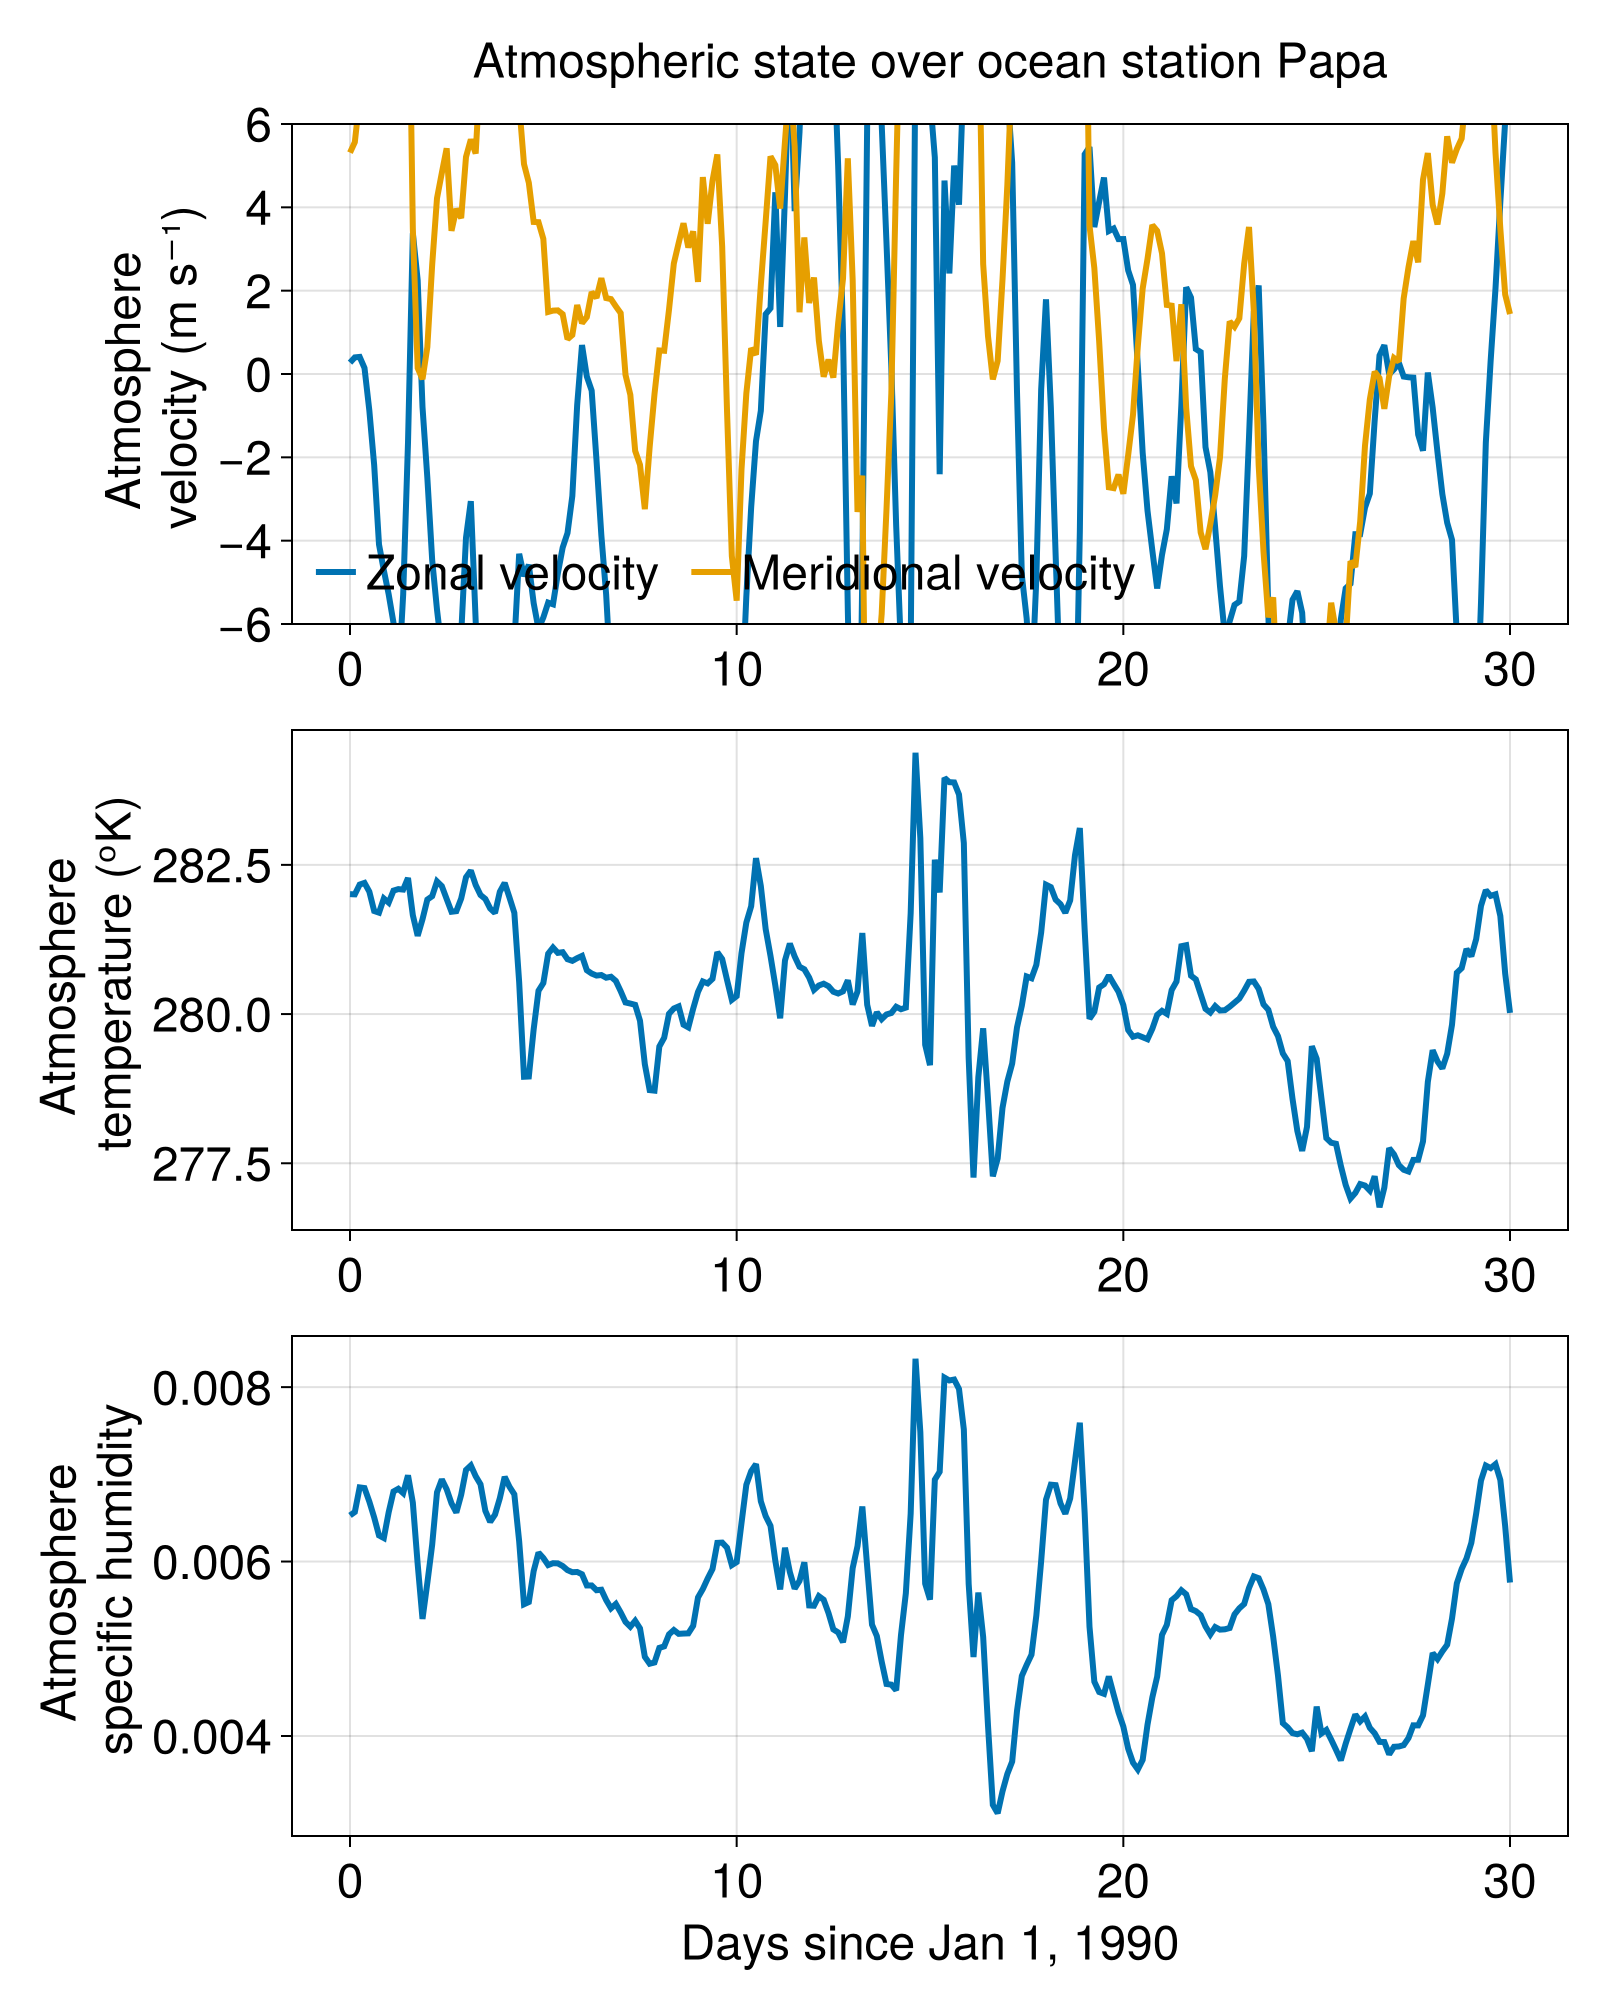

In [5]:
# this builds prescribed jra55 atmosphere forcing at the papa station column
# end_date is the last day needed for the 30-day simulation
atmosphere = JRA55PrescribedAtmosphere(region   = Column(λ★, φ★),
                                       end_date = DateTime(1990, 1, 31), # Last day of the simulation
                                       time_indices_in_memory = 1000)

# this builds prescribed jra55 radiation forcing at the same column
# radiation includes downwelling shortwave + longwave terms
radiation = JRA55PrescribedRadiation(region   = Column(λ★, φ★),
                                     end_date = DateTime(1990, 1, 31),
                                     time_indices_in_memory = 1000)

# this shows the atmosphere grid
# it should also be a tiny single-column grid
atmosphere.grid

# this pulls atmospheric state variables through time
# u + v are wind components; T is air temperature; q is humidity
ua = interior(atmosphere.velocities.u, 1, 1, 1, :)
va = interior(atmosphere.velocities.v, 1, 1, 1, :)
Ta = interior(atmosphere.tracers.T, 1, 1, 1, :)
qa = interior(atmosphere.tracers.q, 1, 1, 1, :)
t_days = atmosphere.times / days

# this loads the plotting package for the atmosphere check plot
using CairoMakie

# this makes the plot text + lines easier to read
set_theme!(Theme(linewidth=3, fontsize=24))

# this creates the atmosphere forcing figure
fig = Figure(size=(800, 1000))
axu = Axis(fig[2, 1]; ylabel="Atmosphere \n velocity (m s⁻¹)")
axT = Axis(fig[3, 1]; ylabel="Atmosphere \n temperature (ᵒK)")
axq = Axis(fig[4, 1]; ylabel="Atmosphere \n specific humidity", xlabel = "Days since Jan 1, 1990")
Label(fig[1, 1], "Atmospheric state over ocean station Papa", tellwidth=false)

# this plots zonal + meridional wind
lines!(axu, t_days, ua, label="Zonal velocity")
lines!(axu, t_days, va, label="Meridional velocity")
ylims!(axu, -6, 6)
axislegend(axu, framevisible=false, nbanks=2, position=:lb)

# this plots air temperature + specific humidity
lines!(axT, t_days, Ta)
lines!(axq, t_days, qa)

# this displays the atmosphere figure in the notebook
current_figure()

In [6]:
# this couples the ocean column to the prescribed atmosphere + radiation
# oceanonlymodel means this is ocean-only, not sea ice
coupled_model = OceanOnlyModel(ocean; atmosphere, radiation)

# this creates the simulation controller
# it uses the ocean timestep and stops at 30 model days
simulation = Simulation(coupled_model, Δt=ocean.Δt, stop_time=30days)

# this stores wall-clock time for progress messages
wall_clock = Ref(time_ns())

# this prints progress + diagnostics during the run
function progress(sim)
    msg = "Ocean Station Papa"
    msg *= string(", iter: ", iteration(sim), ", time: ", prettytime(sim))

    elapsed = 1e-9 * (time_ns() - wall_clock[])
    msg *= string(", wall time: ", prettytime(elapsed))
    wall_clock[] = time_ns()

    u, v, w = sim.model.ocean.model.velocities
    msg *= @sprintf(", max|u|: (%.2e, %.2e)", maximum(abs, u), maximum(abs, v))

    T = sim.model.ocean.model.tracers.T
    S = sim.model.ocean.model.tracers.S
    e = sim.model.ocean.model.tracers.e
    ρ = sim.model.interfaces.ocean_properties.reference_density
    c = sim.model.interfaces.ocean_properties.heat_capacity

    τˣ = first(sim.model.interfaces.net_fluxes.ocean.u)
    τʸ = first(sim.model.interfaces.net_fluxes.ocean.v)
    Q  = first(sim.model.interfaces.net_fluxes.ocean.T) * ρ * c

    u★ = sqrt(sqrt(τˣ^2 + τʸ^2))

    Nz = size(T, 3)
    msg *= @sprintf(", u★: %.2f m s⁻¹", u★)
    msg *= @sprintf(", Q: %.2f W m⁻²",  Q)
    msg *= @sprintf(", T₀: %.2f ᵒC", first(interior(T, 1, 1, Nz)))
    msg *= @sprintf(", extrema(T): (%.2f, %.2f) ᵒC", minimum(T), maximum(T))
    msg *= @sprintf(", S₀: %.2f g/kg", first(interior(S, 1, 1, Nz)))
    msg *= @sprintf(", e₀: %.2e m² s⁻²", first(interior(e, 1, 1, Nz)))

    @info msg

    return nothing
end

# this runs the progress callback every 100 iterations
simulation.callbacks[:progress] = Callback(progress, IterationInterval(100))

# this grabs flux outputs from the coupled model interface
τˣ = simulation.model.interfaces.net_fluxes.ocean.u
τʸ = simulation.model.interfaces.net_fluxes.ocean.v
JT = simulation.model.interfaces.net_fluxes.ocean.T
Jˢ = simulation.model.interfaces.net_fluxes.ocean.S
Jᵛ = simulation.model.interfaces.atmosphere_ocean_interface.fluxes.water_vapor
𝒬ᵀ = simulation.model.interfaces.atmosphere_ocean_interface.fluxes.sensible_heat
𝒬ᵛ = simulation.model.interfaces.atmosphere_ocean_interface.fluxes.latent_heat
ρᵒᶜ = simulation.model.interfaces.ocean_properties.reference_density
cᵒᶜ = simulation.model.interfaces.ocean_properties.heat_capacity

# this builds derived flux + diagnostic outputs
Q = ρᵒᶜ * cᵒᶜ * JT
ρτˣ = ρᵒᶜ * τˣ
ρτʸ = ρᵒᶜ * τʸ
N² = buoyancy_frequency(ocean.model)
κc = ocean.model.closure_fields.κc

# this bundles fluxes, diagnostics, and model state fields for output
fluxes = (; ρτˣ, ρτʸ, Jᵛ, Jˢ, 𝒬ᵛ, 𝒬ᵀ)
auxiliary_fields = (; N², κc)
u, v, w = ocean.model.velocities
T, S, e = ocean.model.tracers
fields = merge((; u, v, T, S, e), auxiliary_fields)

# this merges saved fields + fluxes
outputs = merge(fields, fluxes)

# this makes the output filename
filename = "single_column_omip_$(location_name)"

# this writes output every 3 model hours
ocean.output_writers[:jld2] = JLD2Writer(ocean.model, outputs; filename,
                                         schedule = TimeInterval(3hours),
                                         overwrite_existing = true)

# this runs the simulation
run!(simulation)

┌ Info: Initializing simulation...
└ @ Oceananigans.Simulations C:\Users\meghn\.julia\packages\Oceananigans\NCFoc\src\Simulations\run.jl:309
┌ Info: Ocean Station Papa, iter: 0, time: 0 seconds, wall time: 17.029 seconds, max|u|: (0.00e+00, 0.00e+00), u★: 0.01 m s⁻¹, Q: -27.31 W m⁻², T₀: 6.14 ᵒC, extrema(T): (3.88, 6.14) ᵒC, S₀: 32.51 g/kg, e₀: 0.00e+00 m² s⁻²
└ @ Main c:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\simulation #1\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:44
┌ Info:     ... simulation initialization complete (7.854 seconds)
└ @ Oceananigans.Simulations C:\Users\meghn\.julia\packages\Oceananigans\NCFoc\src\Simulations\run.jl:364
┌ Info: Executing initial time step...
└ @ Oceananigans.Simulations C:\Users\meghn\.julia\packages\Oceananigans\NCFoc\src\Simulations\run.jl:235
┌ Info:     ... initial time step complete (21.524 seconds).
└ @ Oceananigans.Simulations C:\Users\meghn\.julia\packages\Oceananigans\NCFoc\src\Simulations\run.jl:26

In [7]:
# this turns the base filename into the saved jld2 filename
filename *= ".jld2"

# this loads saved model fields
u  = FieldTimeSeries(filename, "u")
v  = FieldTimeSeries(filename, "v")
T  = FieldTimeSeries(filename, "T")
S  = FieldTimeSeries(filename, "S")
e  = FieldTimeSeries(filename, "e")
N² = FieldTimeSeries(filename, "N²")
κ  = FieldTimeSeries(filename, "κc")

# this loads saved fluxes
𝒬ᵛ = FieldTimeSeries(filename, "𝒬ᵛ")
𝒬ᵀ = FieldTimeSeries(filename, "𝒬ᵀ")
Jˢ = FieldTimeSeries(filename, "Jˢ")
Ev = FieldTimeSeries(filename, "Jᵛ")
ρτˣ = FieldTimeSeries(filename, "ρτˣ")
ρτʸ = FieldTimeSeries(filename, "ρτʸ")

# this gets vertical size + saved output times
Nz = size(T, 3)
times = 𝒬ᵀ.times

# this grabs atmosphere + radiation fields for sampling
ua  = atmosphere.velocities.u
va  = atmosphere.velocities.v
Ta  = atmosphere.tracers.T
qa  = atmosphere.tracers.q
ℐꜜˡʷ = radiation.downwelling_longwave
ℐꜜˢʷ = radiation.downwelling_shortwave
Pr  = atmosphere.freshwater_flux.rain
Ps  = atmosphere.freshwater_flux.snow

# this allocates arrays for forcing values sampled at model output times
Nt   = length(times)
uat  = zeros(Nt)
vat  = zeros(Nt)
Tat  = zeros(Nt)
qat  = zeros(Nt)
ℐꜜˢʷt = zeros(Nt)
ℐꜜˡʷt = zeros(Nt)
Pt   = zeros(Nt)

# this samples atmosphere + radiation forcing at each saved output time
for n = 1:Nt
    t = Oceananigans.Units.Time(times[n])
    uat[n]  =  ua[1, 1, 1, t]
    vat[n]  =  va[1, 1, 1, t]
    Tat[n]  =  Ta[1, 1, 1, t]
    qat[n]  =  qa[1, 1, 1, t]
    ℐꜜˢʷt[n] = ℐꜜˢʷ[1, 1, 1, t]
    ℐꜜˡʷt[n] = ℐꜜˡʷ[1, 1, 1, t]
    Pt[n]   =  Pr[1, 1, 1, t] + Ps[1, 1, 1, t]
end

In [9]:
# this builds the summary figure layout
fig = Figure(size=(1800, 1800))

# this creates time series axes
axτ = Axis(fig[1, 1:3], xlabel="Days since Oct 1 1992", ylabel="Wind stress (N m⁻²)")
axQ = Axis(fig[1, 4:6], xlabel="Days since Oct 1 1992", ylabel="Heat flux (W m⁻²)")
axu = Axis(fig[2, 1:3], xlabel="Days since Oct 1 1992", ylabel="Velocities (m s⁻¹)")
axT = Axis(fig[2, 4:6], xlabel="Days since Oct 1 1992", ylabel="Surface temperature (ᵒC)")
axF = Axis(fig[3, 1:3], xlabel="Days since Oct 1 1992", ylabel="Freshwater volume flux (m s⁻¹)")
axS = Axis(fig[3, 4:6], xlabel="Days since Oct 1 1992", ylabel="Surface salinity (g kg⁻¹)")

# this creates vertical profile axes
axuz = Axis(fig[4:5, 1:2], xlabel="Velocities (m s⁻¹)",                ylabel="z (m)")
axTz = Axis(fig[4:5, 3:4], xlabel="Temperature (ᵒC)",                  ylabel="z (m)")
axSz = Axis(fig[4:5, 5:6], xlabel="Salinity (g kg⁻¹)",                 ylabel="z (m)")
axNz = Axis(fig[6:7, 1:2], xlabel="Buoyancy frequency (s⁻²)",          ylabel="z (m)")
axκz = Axis(fig[6:7, 3:4], xlabel="Eddy diffusivity (m² s⁻¹)",         ylabel="z (m)", xscale=log10)
axez = Axis(fig[6:7, 5:6], xlabel="Turbulent kinetic energy (m² s⁻²)", ylabel="z (m)", xscale=log10)

# this adds the main title
title = @sprintf("Single-column simulation at %.2f, %.2f", φ★, λ★)
Label(fig[0, 1:6], title)

# this sets the animated frame index
n = Observable(1)

# this converts times to days since the first output
times = (times .- times[1]) ./days
Nt = length(times)

# this creates the moving time marker for time series panels
tn = @lift times[$n]

# this gets makie's default color palette
colors = Makie.wong_colors()

# this converts density-scaled stress back into stress
ρᵒᶜ = coupled_model.interfaces.ocean_properties.reference_density
τˣ = interior(ρτˣ, 1, 1, 1, :) ./ ρᵒᶜ
τʸ = interior(ρτʸ, 1, 1, 1, :) ./ ρᵒᶜ
u★ = @. (τˣ^2 + τʸ^2)^(1/4)

# this plots ocean velocity + friction velocity
lines!(axu, times, interior(u, 1, 1, Nz, :), color=colors[1], label="Zonal")
lines!(axu, times, interior(v, 1, 1, Nz, :), color=colors[2], label="Meridional")
lines!(axu, times, u★, color=colors[3], label="Ocean-side u★")
vlines!(axu, tn, linewidth=4, color=(:black, 0.5))
axislegend(axu)

# this plots wind stress components
lines!(axτ, times, interior(ρτˣ, 1, 1, 1, :), label="Zonal")
lines!(axτ, times, interior(ρτʸ, 1, 1, 1, :), label="Meridional")
vlines!(axτ, tn, linewidth=4, color=(:black, 0.5))
axislegend(axτ)

# this plots air temperature + ocean surface temperature
lines!(axT, times, Tat[1:Nt] .- 273.15,      color=colors[1], linewidth=2, linestyle=:dash, label="Atmosphere temperature")
lines!(axT, times, interior(T, 1, 1, Nz, :), color=colors[2], linewidth=4, label="Ocean surface temperature")
vlines!(axT, tn, linewidth=4, color=(:black, 0.5))
axislegend(axT)

# this plots heat flux components
lines!(axQ, times, interior(𝒬ᵛ, 1, 1, 1, 1:Nt),    color=colors[2], label="Latent",    linewidth=2)
lines!(axQ, times, interior(𝒬ᵀ, 1, 1, 1, 1:Nt),    color=colors[3], label="Sensible",  linewidth=2)
lines!(axQ, times, - interior(ℐꜜˢʷ, 1, 1, 1, 1:Nt), color=colors[4], label="Shortwave", linewidth=2)
lines!(axQ, times, - interior(ℐꜜˡʷ, 1, 1, 1, 1:Nt), color=colors[5], label="Longwave",  linewidth=2)
vlines!(axQ, tn, linewidth=4, color=(:black, 0.5))
axislegend(axQ)

# this plots freshwater flux + evaporation
lines!(axF, times, Pt[1:Nt], label="Prescribed freshwater flux")
lines!(axF, times, - interior(Ev, 1, 1, 1, 1:Nt), label="Evaporation")
vlines!(axF, tn, linewidth=4, color=(:black, 0.5))
axislegend(axF)

# this plots surface salinity
lines!(axS, times, interior(S, 1, 1, Nz, :))
vlines!(axS, tn, linewidth=4, color=(:black, 0.5))

# this defines animated vertical profiles
un  = @lift u[$n]
vn  = @lift v[$n]
Tn  = @lift T[$n]
Sn  = @lift S[$n]
κn  = @lift κ[$n]
en  = @lift e[$n]
N²n = @lift N²[$n]

# this plots vertical profiles
scatterlines!(axuz, un, label="u")
scatterlines!(axuz, vn, label="v")
scatterlines!(axTz, Tn)
scatterlines!(axSz, Sn)
scatterlines!(axez, en)
scatterlines!(axNz, N²n)
scatterlines!(axκz, κn)

axislegend(axuz)

#Makie.Legend()

# guard against ulim=0, which makes makie's symmetric xlims collapse to (0, 0) and triggers an invalid colorrange error
ulim = max(maximum(abs, u), maximum(abs, v), 1e-10)
xlims!(axuz, -ulim, ulim)

# this sets temperature profile limits
Tmin, Tmax = extrema(T)
xlims!(axTz, Tmin - 0.1, Tmax + 0.1)

# this sets buoyancy frequency limits
Nmax = maximum(N²)
xlims!(axNz, -Nmax/10, Nmax * 1.05)

# this sets eddy diffusivity limits
κmax = maximum(κ)
xlims!(axκz, 1e-9, κmax * 1.1)

# this sets turbulent kinetic energy limits
emax = maximum(e)
xlims!(axez, 1e-11, emax * 1.1)

# this sets salinity limits
Smin, Smax = extrema(S)
xlims!(axSz, Smin - 0.2, Smax + 0.2)

# this records the animation
CairoMakie.record(fig, "single_column_profiles.mp4", 1:Nt, framerate=24) do nn
    @info "Drawing frame $nn of $Nt..."
    n[] = nn
end

┌ Info: Drawing frame 1 of 241...
└ @ Main c:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\simulation #1\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sZmlsZQ==.jl:128
┌ Info: Drawing frame 2 of 241...
└ @ Main c:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\simulation #1\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sZmlsZQ==.jl:128
┌ Info: Drawing frame 3 of 241...
└ @ Main c:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\simulation #1\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sZmlsZQ==.jl:128
┌ Info: Drawing frame 4 of 241...
└ @ Main c:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\simulation #1\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sZmlsZQ==.jl:128
┌ Info: Drawing frame 5 of 241...
└ @ Main c:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\simulation #1\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sZmlsZQ==.jl:128
┌ Info: Drawing frame 6 of 241...
└ @ Main c:\Users\meg

"single_column_profiles.mp4"